In [11]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [17]:



def bs_call_put(S0, K, T, sigma, r=0.0, q=0.0):
    K = np.asarray(K, dtype=float)

    F = S0 * np.exp((r - q) * T)
    df = np.exp(-r * T)

    sqrt_T = np.sqrt(T)

    d1 = (
        np.log(F / K) + 0.5 * sigma**2 * T
    ) / (sigma * sqrt_T)

    d2 = d1 - sigma * sqrt_T

    call = df * (
        F * norm.cdf(d1)
        - K * norm.cdf(d2)
    )

    put = df * (
        K * norm.cdf(-d2)
        - F * norm.cdf(-d1)
    )

    return call, put


def variance_strike_from_option_strip(
    S0=100,
    T=1.0,
    sigma_imp=0.2,  # flat vol case, does not yet demonstrate the redesign VIX: capture the whole skew
    r=0.0,
    q=0.0
):
    F = S0 * np.exp((r - q) * T)

    strikes = np.linspace(20, 250, 2000) # brute force, fine grid

    calls, puts = bs_call_put(
        S0=S0,
        K=strikes,
        T=T,
        sigma=sigma_imp,
        r=r,
        q=q
    )

    # OTM option prices:
    # puts below the forward and calls above the forward
    Q = np.where(strikes < F, puts, calls)

    dK = np.gradient(strikes) # cannot handle irregular spacing. dK = strikes[1] - strikes[0]

    contribution = (
        (2.0 / T)
        * dK
        * Q
        / strikes**2
    )

    K_var = np.sum(contribution)  # no explicit E0 correction term

    return strikes, K_var, contribution, F

# realistic, coarse, evenly spaced strike grid(a small number of real, tradeable strikes) + correction term
# a huge number of idealized strikes + no correction term
# these two may converge to the same number, but slowing

In [19]:
strikes, K_var, contribution, F = (
    variance_strike_from_option_strip()
)

print("Variance strike:", K_var)
print("Volatility strike:", np.sqrt(K_var))

Variance strike: 0.03999993600605743
Volatility strike: 0.1999998400150796


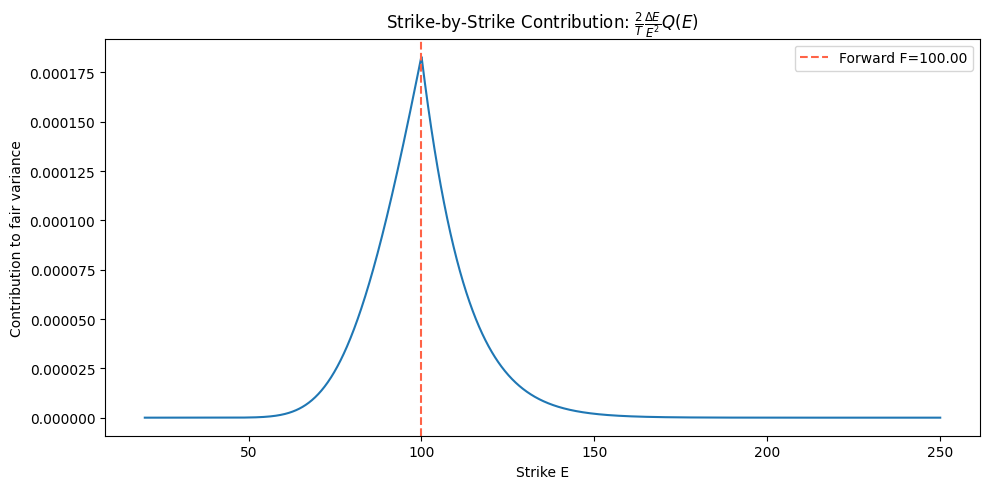

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(strikes, contribution)
plt.axvline(F, color='tomato', linestyle="--", label=f"Forward F={F:.2f}")
plt.xlabel("Strike E")
plt.ylabel("Contribution to fair variance")
plt.title(r"Strike-by-Strike Contribution: $\frac{2}{T}\frac{\Delta E}{E^2}Q(E)$")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [40]:
"""


Two-panel decomposition of the Breeden-Litzenberger / Carr-Madan variance
replication strip:

  Left panel:  the market input   -- Q(K), the OTM option price at each strike
  Right panel: the pure math input -- dK/K^2, the Carr-Madan weight

Splitting these apart (rather than plotting their product, 2/T * Q(K)/K^2 * dK,
as a single "contribution" curve) makes it visually obvious that only the left
panel depends on the market (volatility level, skew, smile); the right panel
is a fixed function of the strike grid alone and would look identical no
matter what smile you fed into Q(K).
"""



def bs_call_put(S0, K, T, sigma, r=0.0, q=0.0):
    """Undiscounted-forward Black-Scholes call and put prices."""
    K = np.asarray(K, dtype=float)
    F = S0 * np.exp((r - q) * T)
    df = np.exp(-r * T)
    sqrt_T = np.sqrt(T)

    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T

    call = df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    put = df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return call, put


# --- Setup: adjust these to match your own scenario ---
S0, T, sigma, r, q = 100.0, 1.0, 0.2, 0.0, 0.0
F = S0 * np.exp((r - q) * T)

strikes = np.linspace(50, 150, 201)
dK = strikes[1] - strikes[0]  # uniform grid spacing

calls, puts = bs_call_put(S0, strikes, T, sigma, r, q)
Q = np.where(strikes < F, puts, calls)   # OTM strip: puts below F, calls above F
weight = dK / strikes**2                  # discretized Carr-Madan weight at each strike




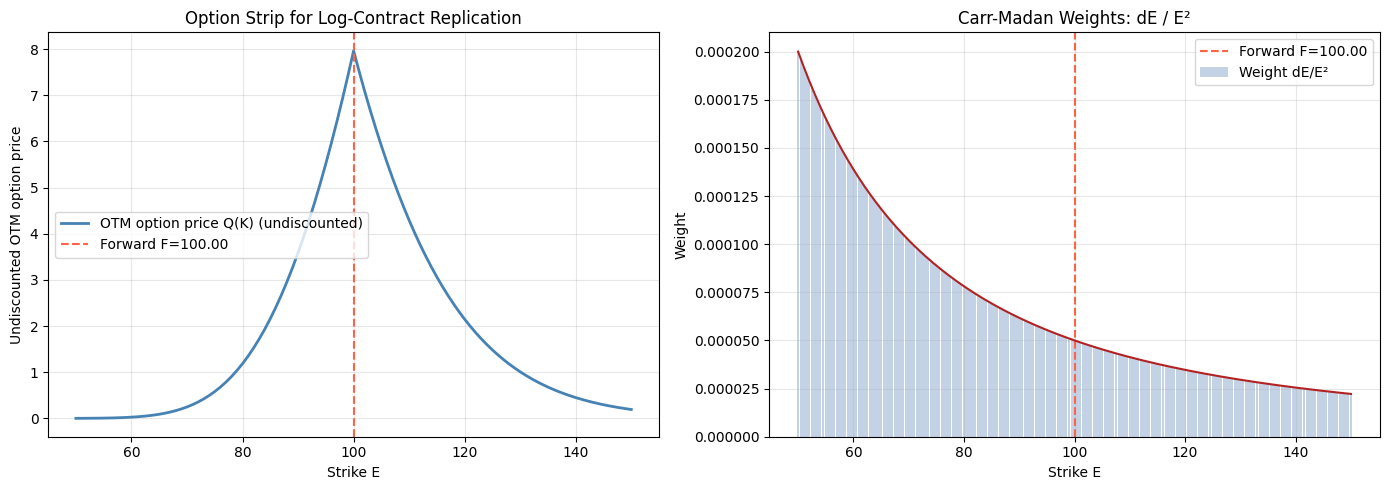

Forward F = 100.00
Peak OTM price (near F) ≈ 7.966
Weight at K=50: 0.000200   Weight at K=150: 0.000022   ratio = 9.00x


In [50]:

#plt.rcParams["axes.grid"] = True
#plt.rcParams["grid.alpha"] = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the option strip itself (the market-dependent piece)
axes[0].plot(strikes, Q, color="steelblue", lw=2, label="OTM option price Q(K) (undiscounted)")
axes[0].axvline(F, color="tomato", linestyle="--", lw=1.5, label=f"Forward F={F:.2f}")
axes[0].set_xlabel("Strike E")
axes[0].set_ylabel("Undiscounted OTM option price")
axes[0].set_title("Option Strip for Log-Contract Replication")
axes[0].legend()

# Right: the Carr-Madan weight (the pure-math piece -- no volatility input at all)
axes[1].axvline(F, color="tomato", linestyle="--", lw=1.5, label=f"Forward F={F:.2f}")
axes[1].bar(strikes, weight, width=dK * 0.9, color="lightsteelblue", alpha=0.75, label="Weight dE/E²")
axes[1].plot(strikes, weight, color="firebrick", lw=1.5)  # envelope tracing the bar tops
axes[1].set_xlabel("Strike E")
axes[1].set_ylabel("Weight")
axes[1].set_title("Carr-Madan Weights: dE / E²")
axes[1].legend()

fig.tight_layout()
#fig.savefig("option_strip_and_weights.png", dpi=150)
plt.show()

print(f"Forward F = {F:.2f}")
print(f"Peak OTM price (near F) ≈ {Q.max():.3f}")
print(f"Weight at K=50: {dK/50**2:.6f}   Weight at K=150: {dK/150**2:.6f}   "
      f"ratio = {(dK/50**2)/(dK/150**2):.2f}x")